# 06 — Output interpreteren

Deze notebook hoort bij [`docs/output-begrijpen.md`](../docs/output-begrijpen.md). We:

1. Draaien de pipeline en bekijken **echte output**
2. Leggen elke kolomgroep uit (identifiers, voorspellingen, actuelen, foutmaten)
3. Voegen **realisatie** toe en koppelen elk modelaan zijn werkelijke fout
4. Exporteren naar Excel — exact zoals de CLI dat doet

> ℹ️ We draaien `-d c` (cumulatief): geen individuele data nodig. Kolommen die
> alleen bij `-d both` voorkomen (`Ensemble_prediction`, `SARIMA_individual`)
> worden onderaan benoemd.


> ⚠️ **De demodata is Radboud (WO).** De voorbeelden gebruiken WO-opleidingen
> (`B Psychologie`, `B Bedrijfskunde`, …). Voor een hogeschool met eigen data:
> 1. Vervang `data/input/vooraanmeldingen_cumulatief.csv` door je eigen ETL-output
> 2. Pas `PROGRAMMA`, `HERKOMST`, `PREDICT_YEAR`, `PREDICT_WEEK` aan naar wat in jouw data zit
> 3. HBO-specifiek: typisch meer numerus-fixus opleidingen, weinig masters, andere 1-mei-deadline-effecten.


In [1]:
# --- Standaard setup voor alle studentprognose-notebooks ---
import sys
from pathlib import Path

# Maak _helpers.py importeerbaar en ga naar projectroot
NOTEBOOKS_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
sys.path.insert(0, str(NOTEBOOKS_DIR))

from _helpers import project_root, setup_matplotlib  # noqa: E402
project_root()
setup_matplotlib()

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print("Werkmap:", Path.cwd())
print("Python :", sys.version.split()[0])


Werkmap: /home/muhammet/studentprognose
Python : 3.12.12


In [2]:
from _helpers import load_cumulative

data_cumulative, data_studentcount, data_cumulative_raw = load_cumulative()
print(f"Cumulatieve telregels:    {len(data_cumulative):,}")
print(f"Aantal opleidingen:       {data_cumulative['Croho groepeernaam'].nunique()}")
print(f"Historische realisatie:   {len(data_studentcount):,} rijen (Aantal_studenten per opleiding/jaar)")


Cumulatieve telregels:    25,271
Aantal opleidingen:       18
Historische realisatie:   432 rijen (Aantal_studenten per opleiding/jaar)


## 1. Pipeline draaien (cumulatief, in-memory)

We voorspellen **2023** vanaf peilweek **12** zodat we straks met de werkelijke
realisatie kunnen vergelijken. De per-opleiding-spam wordt onderdrukt — de
pipeline print normaal voor élke combinatie een regel.

> 🕒 Duurt typisch ~20–40 sec op demodata.


In [3]:
from studentprognose import run_pipeline_from_dataframes, DataOption
from _helpers import suppress_stdout

PREDICT_YEAR = 2023
PREDICT_WEEK = 12

with suppress_stdout():
    result = run_pipeline_from_dataframes(
        year=PREDICT_YEAR, week=PREDICT_WEEK,
        data_cumulative=data_cumulative_raw,
        data_student_numbers=data_studentcount,
        dataset=DataOption.CUMULATIVE, save_output=False,
    )
print(f"Output: {result.shape[0]} rijen × {result.shape[1]} kolommen")
print(f"Opleidingen: {result['Croho groepeernaam'].nunique()}")


Output: 1458 rijen × 23 kolommen
Opleidingen: 18


## 2. Kolomgroepen

De output heeft vier groepen kolommen. Bij `-d c` zijn niet allemaal gevuld:


In [4]:
identifier_cols = [c for c in ["Croho groepeernaam", "Herkomst", "Examentype", "Collegejaar", "Weeknummer", "Faculteit"] if c in result.columns]
prediction_cols = [c for c in ["SARIMA_cumulative", "SARIMA_individual", "Prognose_ratio", "Ensemble_prediction", "Baseline"] if c in result.columns]
actuele_cols    = [c for c in ["Gewogen vooraanmelders", "Ongewogen vooraanmelders", "Aantal aanmelders met 1 aanmelding", "Inschrijvingen"] if c in result.columns]
error_cols      = sorted([c for c in result.columns if c.startswith(("MAE_", "MAPE_"))])

print("A. Identifier-kolommen:")
for c in identifier_cols: print(f"  - {c}")
print("\nB. Voorspelkolommen:")
for c in prediction_cols:
    pct_filled = result[c].notna().mean() * 100
    print(f"  - {c:25s}  {pct_filled:5.1f}% gevuld")
print("\nC. Actuele cijfers (peilweek-stand):")
for c in actuele_cols: print(f"  - {c}")
print("\nD. Foutmaten (historische prestatie):")
for c in error_cols: print(f"  - {c}")


A. Identifier-kolommen:
  - Croho groepeernaam
  - Herkomst
  - Examentype
  - Collegejaar
  - Weeknummer
  - Faculteit

B. Voorspelkolommen:
  - SARIMA_cumulative            3.7% gevuld
  - SARIMA_individual            0.0% gevuld
  - Prognose_ratio             100.0% gevuld
  - Baseline                   100.0% gevuld

C. Actuele cijfers (peilweek-stand):
  - Gewogen vooraanmelders
  - Ongewogen vooraanmelders
  - Aantal aanmelders met 1 aanmelding
  - Inschrijvingen

D. Foutmaten (historische prestatie):
  - MAE_Prognose_ratio
  - MAE_SARIMA_cumulative
  - MAPE_Prognose_ratio
  - MAPE_SARIMA_cumulative


> ⚠️ `Ensemble_prediction` en `SARIMA_individual` zijn hier **leeg** omdat we
> `-d c` (alleen cumulatief) draaien. In `-d both` zijn ze gevuld.
> Zie [bekende valkuil](../docs/aan-de-slag.md#bekende-valkuil-stille-modus-downgrade).

## 3. Voorspelling × Realisatie — per opleiding

We voegen de realisatie toe via de helper `with_realisatie()` en zien direct
de fout per opleiding.


In [5]:
from _helpers import with_realisatie

# Filter eerst op peilweek (SARIMA staat alleen daar; ratio voor alle weken)
result_peilweek = result[result["Weeknummer"] == PREDICT_WEEK]

# Aggregeer SARIMA + ratio per opleiding (sommeer over herkomst)
agg = (
    result_peilweek[result_peilweek["Examentype"] == "Bachelor"]
    .groupby(["Croho groepeernaam", "Collegejaar", "Examentype"], as_index=False)
    [["SARIMA_cumulative", "Prognose_ratio"]]
    .sum()
)
real = (
    data_studentcount[(data_studentcount["Examentype"] == "Bachelor")
                      & (data_studentcount["Collegejaar"] == PREDICT_YEAR)]
    .groupby(["Croho groepeernaam", "Collegejaar", "Examentype"], as_index=False)
    ["Aantal_studenten"].sum()
    .rename(columns={"Aantal_studenten": "Realisatie"})
)

vergelijk = agg.merge(real, on=["Croho groepeernaam", "Collegejaar", "Examentype"])
vergelijk["Fout_SARIMA"] = (vergelijk["SARIMA_cumulative"] - vergelijk["Realisatie"]).round(0)
vergelijk["Fout_Ratio"]  = (vergelijk["Prognose_ratio"]    - vergelijk["Realisatie"]).round(0)
vergelijk["%_SARIMA"] = ((vergelijk["SARIMA_cumulative"] - vergelijk["Realisatie"]) / vergelijk["Realisatie"] * 100).round(1)
vergelijk["%_Ratio"]  = ((vergelijk["Prognose_ratio"]    - vergelijk["Realisatie"]) / vergelijk["Realisatie"] * 100).round(1)

vergelijk[["Croho groepeernaam", "Realisatie", "SARIMA_cumulative", "%_SARIMA", "Prognose_ratio", "%_Ratio"]].sort_values("Realisatie", ascending=False)


,Croho groepeernaam,Realisatie,SARIMA_cumulative,%_SARIMA,Prognose_ratio,%_Ratio
9,B Psychologie,553,556.0,0.5,564.770824,2.1
4,B Geneeskunde,521,444.0,-14.8,502.946981,-3.5
6,B Kunstmatige Intelligentie,457,417.0,-8.8,417.566609,-8.6
0,B Bedrijfskunde,421,352.0,-16.4,384.553134,-8.7
1,B Biomedische Wetenschappen,266,237.0,-10.9,218.142843,-18.0
2,B Communicatiewetenschap,214,226.0,5.6,242.456561,13.3
8,B Politicologie,196,196.0,0.0,222.995158,13.8
5,B Geschiedenis,150,152.0,1.3,142.813078,-4.8
11,B Wiskunde,125,142.0,13.6,145.576857,16.5
7,B Natuurkunde,122,139.0,13.9,143.530924,17.6


## 4. MAE vs MAPE in deze data

| Metric | Eenheid | Interpretatie |
|--------|---------|---------------|
| **MAE** (Mean Absolute Error) | studenten | Hoeveel studenten gemiddeld afwijking |
| **MAPE** (Mean Absolute Percentage Error) | % | Procentuele afwijking — vergelijkbaar tussen grote en kleine opleidingen |

> 📌 Foutmaten zijn berekend **exclusief numerus fixus**: bij NF wordt de
> prognose afgekapt, wat foutvergelijking met reguliere opleidingen vertekenend
> maakt.


In [6]:
samenvatting = pd.DataFrame({
    "Model": ["SARIMA cumulatief", "Ratio-baseline"],
    "MAE (studenten)": [vergelijk["Fout_SARIMA"].abs().mean().round(1),
                        vergelijk["Fout_Ratio"].abs().mean().round(1)],
    "MAPE (%)":         [vergelijk["%_SARIMA"].abs().mean().round(1),
                        vergelijk["%_Ratio"].abs().mean().round(1)],
})
samenvatting


,Model,MAE (studenten),MAPE (%)
0,SARIMA cumulatief,24.0,9.0
1,Ratio-baseline,23.4,11.0


## 5. Visualisatie: voorspelling vs. realisatie


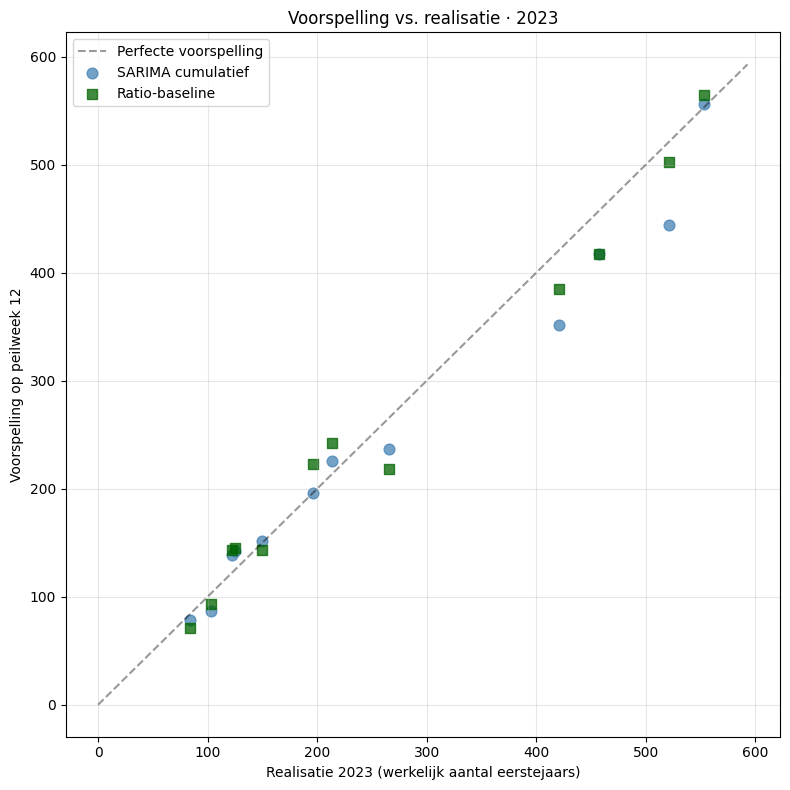

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
m = vergelijk[["Realisatie", "SARIMA_cumulative", "Prognose_ratio"]].max().max() * 1.05
ax.plot([0, m], [0, m], "k--", alpha=0.4, label="Perfecte voorspelling")
ax.scatter(vergelijk["Realisatie"], vergelijk["SARIMA_cumulative"],
           s=60, alpha=0.75, color="steelblue", label="SARIMA cumulatief")
ax.scatter(vergelijk["Realisatie"], vergelijk["Prognose_ratio"],
           s=60, alpha=0.75, color="darkgreen", marker="s", label="Ratio-baseline")
ax.set_xlabel(f"Realisatie {PREDICT_YEAR} (werkelijk aantal eerstejaars)")
ax.set_ylabel(f"Voorspelling op peilweek {PREDICT_WEEK}")
ax.set_title(f"Voorspelling vs. realisatie · {PREDICT_YEAR}")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 6. Exporteren naar Excel

Exact wat de CLI in `data/output/` schrijft. Een hogeschool gebruikt dit voor
deling met facultaire planners, controle, dashboards, etc.


In [8]:
output_path = Path("data/output/notebook_export_2023_wk12.xlsx")
output_path.parent.mkdir(parents=True, exist_ok=True)

# Voeg realisatie + fouten toe en sla op
export = result[result["Examentype"] == "Bachelor"].copy()
export_agg = vergelijk.copy()
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    export.to_excel(writer, sheet_name="raw_output_per_herkomst", index=False)
    export_agg.to_excel(writer, sheet_name="aggregaat_met_realisatie", index=False)
    samenvatting.to_excel(writer, sheet_name="modelvergelijking", index=False)

print(f"✅ Geschreven: {output_path}")
print(f"   Sheets: raw_output_per_herkomst, aggregaat_met_realisatie, modelvergelijking")
print(f"   Groot {output_path.stat().st_size / 1024:.1f} KB")


✅ Geschreven: data/output/notebook_export_2023_wk12.xlsx
   Sheets: raw_output_per_herkomst, aggregaat_met_realisatie, modelvergelijking
   Groot 134.0 KB


## 7. Wanneer is een prognose betrouwbaar? — Beslisregels

**Meer vertrouwen:**
- De modellen liggen dicht bij elkaar (consensus tussen SARIMA en ratio)
- Historische MAE is klein in verhouding tot het cohort
- Peilweek ≥ 10 (genoeg aanmeldata verzameld)

**Minder vertrouwen:**
- Grote spreiding tussen modellen — beoordeel ze los van elkaar
- Hoge historische MAE / MAPE
- Opleiding met weinig historie of klein cohort
- Vroeg in het jaar (peilweek < 6)
- Jaar na een uitzondering (COVID, beleidsingreep)

## 8. Het Plotly-dashboard (opt-in)

Met `--dashboard` genereert de CLI naast de Excel-output interactieve HTML
onder `data/output/visualisaties/`:

```bash
studentprognose --dashboard -d c -y 2024 -w 12
```

- `final/dashboard.html` — altijd
- `cumulative/dashboard.html` — bij `-d c` of `-d b`
- `individual/dashboard.html` — bij `-d i` of `-d b`

> 📌 Dashboard toont alleen de **laatste** week bij multi-week runs. Excel
> bevat wel alle weken.
